In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv(r'C:\PCAMY\Projet_Churn\WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Premiers regards
print("Shape :", df.shape)
print("\nApercu :")
print(df.head())
print("\nTypes :")
print(df.dtypes)
print("\nDistribution Churn :")
print(df['Churn'].value_counts())

Shape : (7043, 21)

Apercu :
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

In [32]:
# ============================================
# Exploration & Nettoyage
# ============================================

# Valeurs manquantes
print("Valeurs manquantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges est en object alors qu'il devrait être float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("\nNaN après conversion TotalCharges :", df['TotalCharges'].isnull().sum())

# Remplir les NaN par la médiane
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encoder Churn en 0/1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Supprimer customerID (inutile pour le modèle)
df.drop('customerID', axis=1, inplace=True)

print("\nShape après nettoyage :", df.shape)
print("\nTypes après nettoyage :")
print(df.dtypes)

Valeurs manquantes :
Series([], dtype: int64)

NaN après conversion TotalCharges : 11

Shape après nettoyage : (7043, 20)

Types après nettoyage :
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


C:\Users\patri\AppData\Local\Temp\ipykernel_38380\490923379.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


Shape après encodage : (7043, 24)
   SeniorCitizen  Partner  Dependents  tenure  PhoneService     MultipleLines  \
0              0        1           0       1             0  No phone service   
1              0        0           0      34             1                No   
2              0        0           0       2             1                No   
3              0        0           0      45             0  No phone service   
4              0        0           0       2             1                No   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  ...  \
0               0             1                 0            0  ...   
1               1             0                 1            0  ...   
2               1             1                 0            0  ...   
3               1             0                 1            1  ...   
4               0             0                 0            0  ...   

   TotalCharges  Churn  gender_Male  InternetService

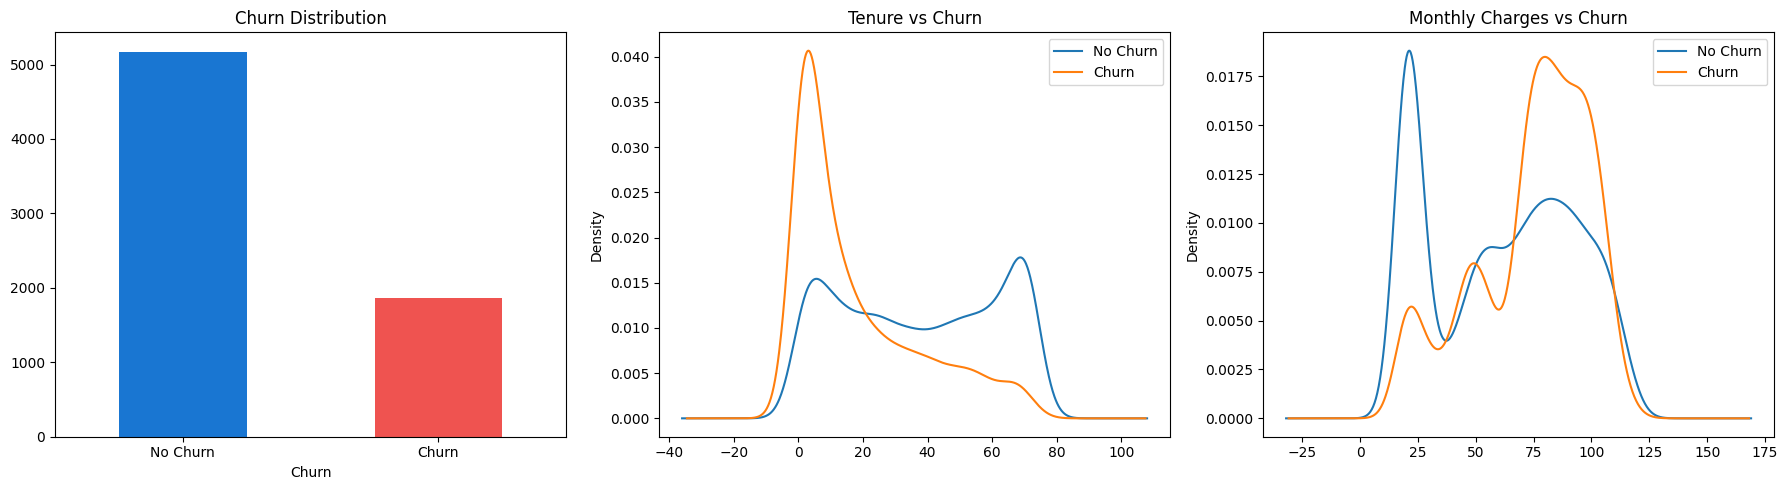

In [33]:
# ============================================
# Encodage des variables catégorielles
# ============================================

# Colonnes binaires Yes/No → 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

# Colonnes avec plus de 2 valeurs → One-Hot Encoding
df = pd.get_dummies(df, columns=['gender', 'InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

# SeniorCitizen est déjà en 0/1
print("Shape après encodage :", df.shape)
print(df.head())

# ============================================
# Visualisations
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution Churn
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#1976D2', '#EF5350'])
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Tenure vs Churn
df.groupby('Churn')['tenure'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Tenure vs Churn')
axes[1].legend(['No Churn', 'Churn'])

# MonthlyCharges vs Churn
df.groupby('Churn')['MonthlyCharges'].plot(kind='kde', ax=axes[2], legend=True)
axes[2].set_title('Monthly Charges vs Churn')
axes[2].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

In [34]:
# Corriger MultipleLines oubliée
df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': 0})

# Convertir les booléens en int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("Types après correction :")
print(df.dtypes)
print("\nShape finale :", df.shape)

Types après correction :
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                int64
InternetService_Fiber optic                int64
InternetService_No                         int64
Contract_One year                          i

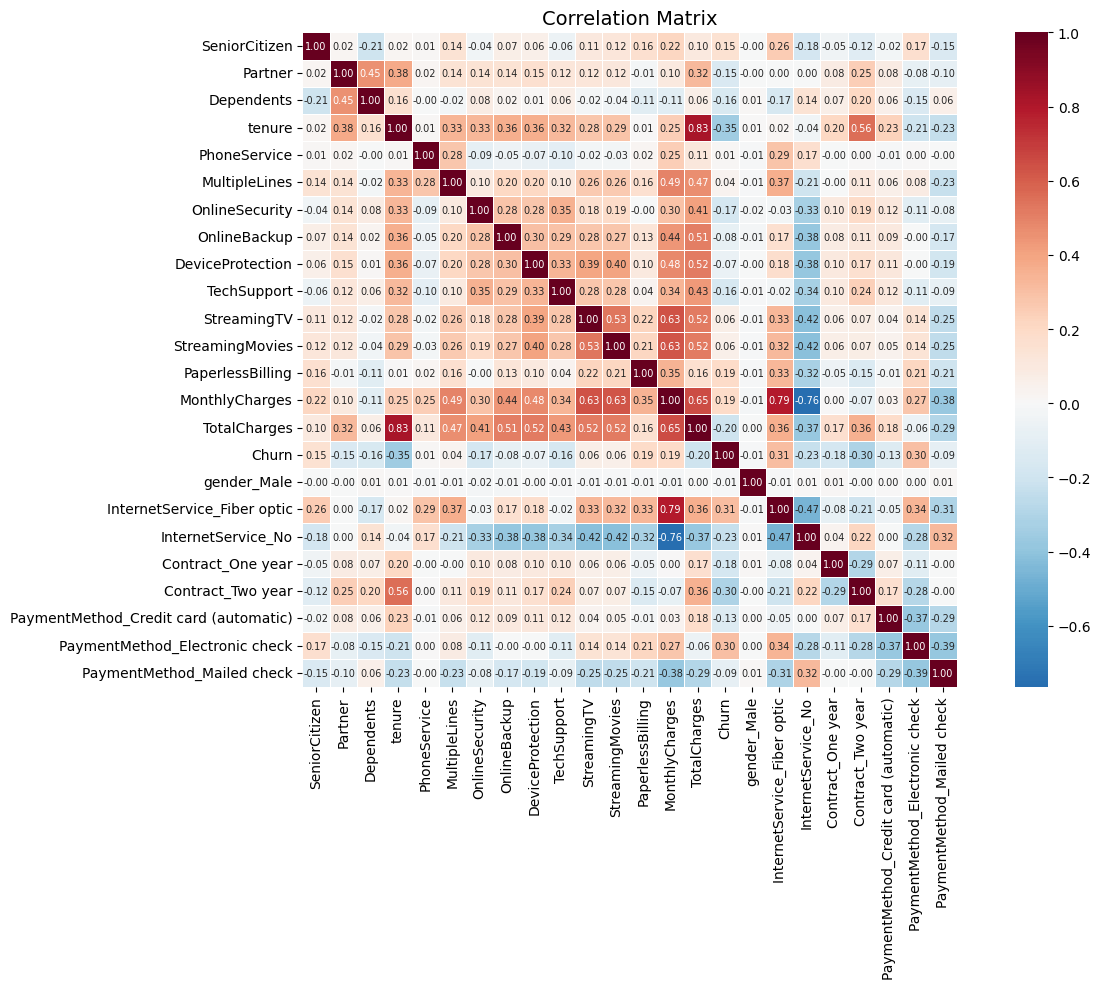


Top corrélations avec Churn :
Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV                              0.063228
StreamingMovies                          0.061382
MultipleLines                            0.040102
PhoneService                             0.011942
gender_Male                             -0.008612
DeviceProtection                        -0.066160
OnlineBackup                            -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport                             -0.164674
OnlineSecurity                          -0.171226
Contract_One year  

In [35]:
# ============================================
# Matrice de corrélation
# ============================================

plt.figure(figsize=(14, 10))
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Top corrélations avec Churn
print("\nTop corrélations avec Churn :")
print(corr['Churn'].sort_values(ascending=False).to_string())

In [36]:
# ============================================
# Split Train / Test
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("\nDistribution churn train :", y_train.value_counts().to_dict())
print("Distribution churn test  :", y_test.value_counts().to_dict())

X_train : (5634, 23)
X_test  : (1409, 23)

Distribution churn train : {0: 4139, 1: 1495}
Distribution churn test  : {0: 1035, 1: 374}


In [37]:
# Vérifier où sont les NaN
print(df.isnull().sum()[df.isnull().sum() > 0])

# Remplir les NaN restants
df.fillna(df.median(numeric_only=True), inplace=True)

# Vérifier
print("\nNaN restants :", df.isnull().sum().sum())

TotalCharges    11
dtype: int64

NaN restants : 0


In [38]:
# Nettoyage NaN
df.fillna(df.median(numeric_only=True), inplace=True)

# Re-split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("NaN restants X_train :", np.isnan(X_train).sum())
print("NaN restants X_test  :", np.isnan(X_test).sum())

NaN restants X_train : 0
NaN restants X_test  : 0


In [39]:
# ============================================
# Modèles ML
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
        
    results[name] = {
        'model': model,
        'auc': round(roc_auc_score(y_test, y_proba), 4),
        'report': classification_report(y_test, y_pred)
    }
    
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"AUC-ROC : {results[name]['auc']}")
    print(results[name]['report'])


Logistic Regression
AUC-ROC : 0.8417
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Random Forest
AUC-ROC : 0.8257
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


XGBoost
AUC-ROC : 0.8214
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.54      0.57       374

    accuracy                           0.79      1409
   macro avg       0.72      0.7

In [40]:
# ============================================
# Amélioration avec class_weight
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # ← compense le déséquilibre 73/27
)

model_balanced.fit(X_train, y_train)
y_pred = model_balanced.predict(X_test)
y_proba = model_balanced.predict_proba(X_test)[:, 1]

print(f"AUC-ROC : {round(roc_auc_score(y_test, y_proba), 4)}")
print(classification_report(y_test, y_pred))

AUC-ROC : 0.8414
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



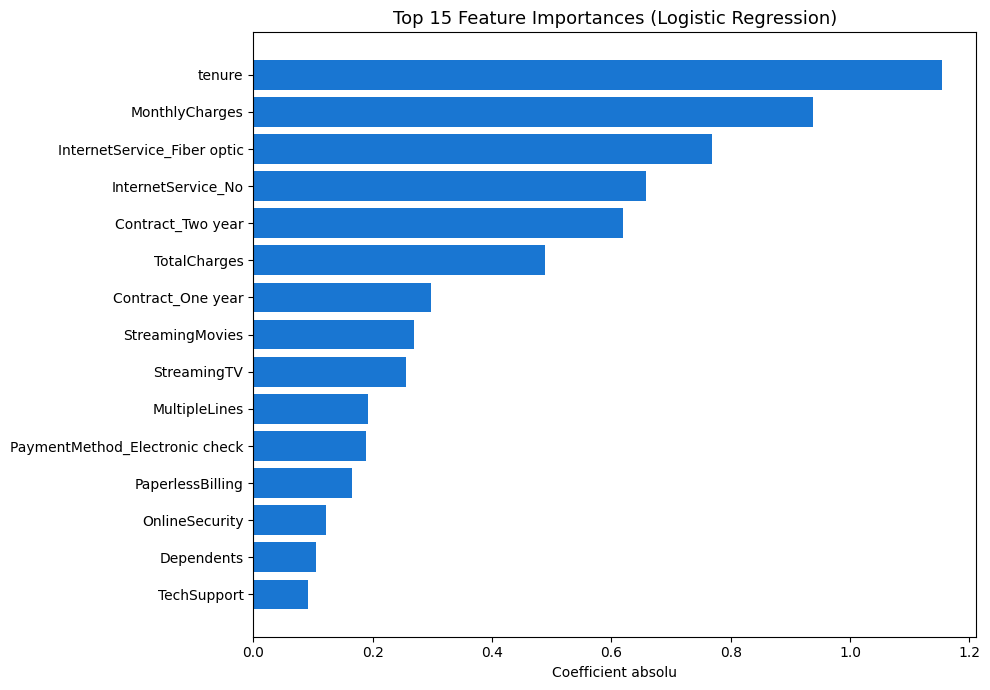

In [41]:
# ============================================
# Feature Importance
# ============================================
feature_names = df.drop('Churn', axis=1).columns

importance = pd.DataFrame({
    'feature': feature_names,
    'importance': np.abs(model_balanced.coef_[0])
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(10, 7))
plt.barh(importance['feature'], importance['importance'], color='#1976D2')
plt.title('Top 15 Feature Importances (Logistic Regression)', fontsize=13)
plt.xlabel('Coefficient absolu')
plt.tight_layout()
plt.show()

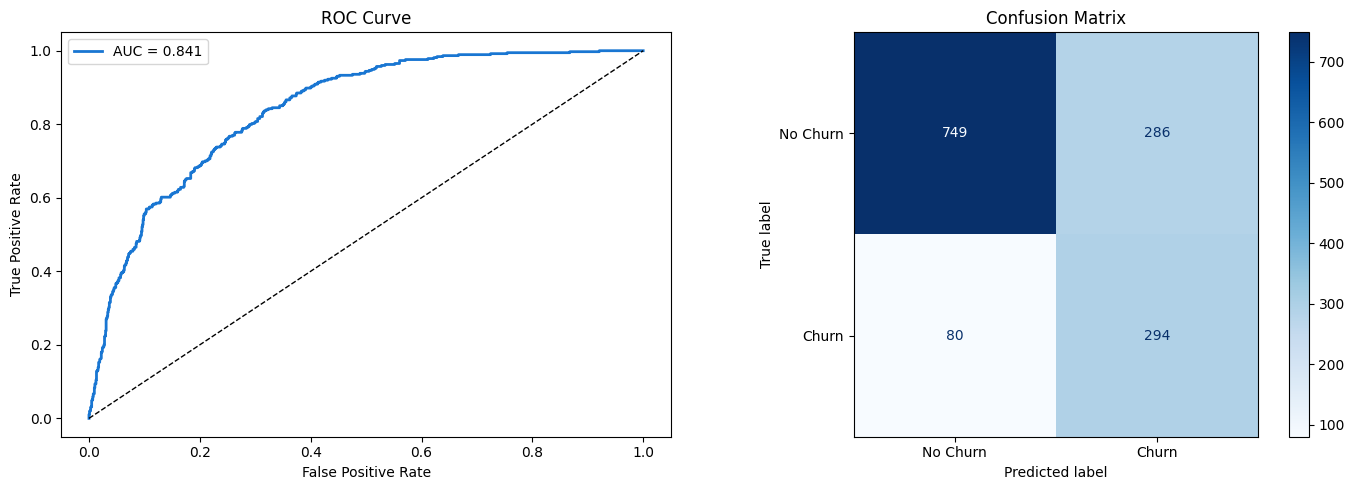

In [42]:
# ============================================
# ROC Curve + Confusion Matrix
# ============================================
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#1976D2', lw=2, label=f'AUC = 0.841')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


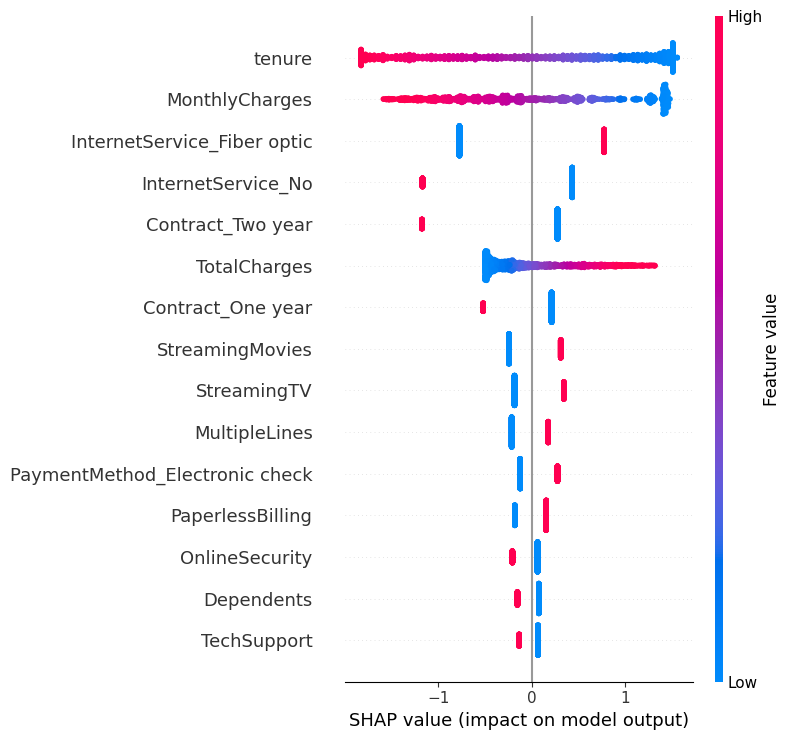

In [43]:
import shap

# Créer l'explainer
explainer = shap.LinearExplainer(model_balanced, X_train)
shap_values = explainer.shap_values(X_test)

feature_names = list(df.drop('Churn', axis=1).columns)

# ============================================
# 1. Beeswarm plot — importance globale
# ============================================
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="dot",
    max_display=15
)

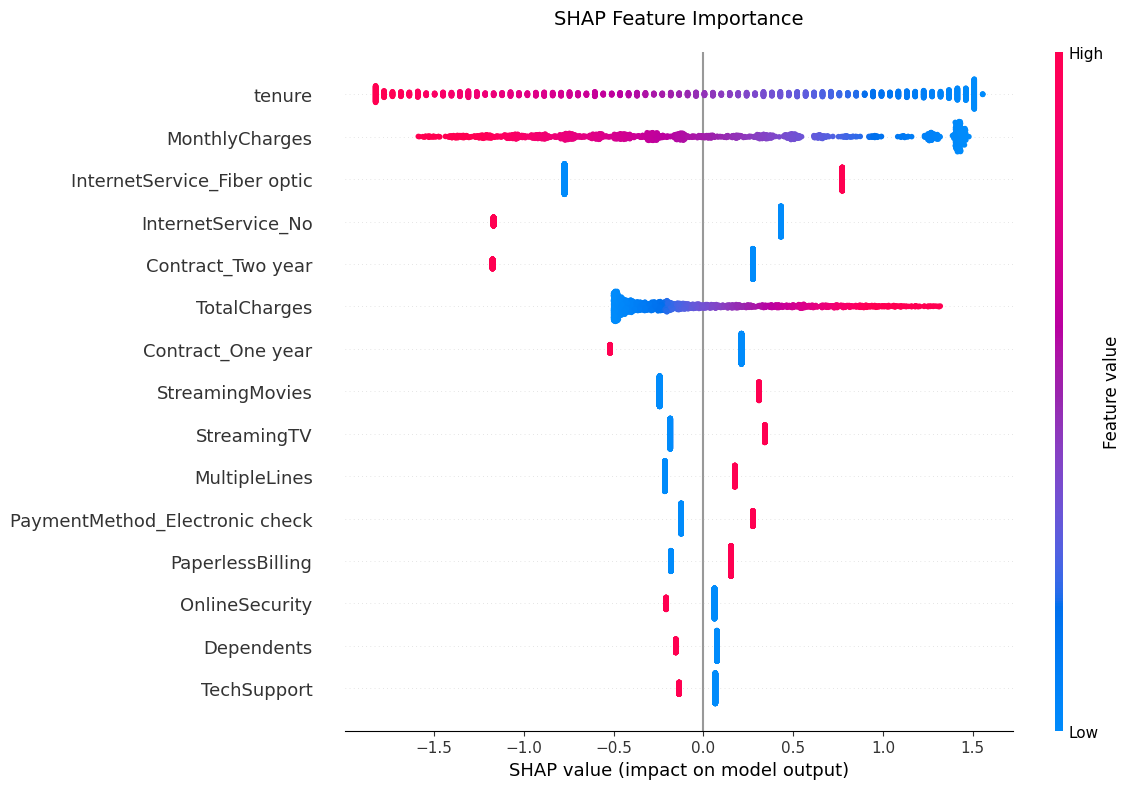

In [44]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    max_display=15,
    plot_size=(12, 8),
    show=False
)
plt.title('SHAP Feature Importance', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

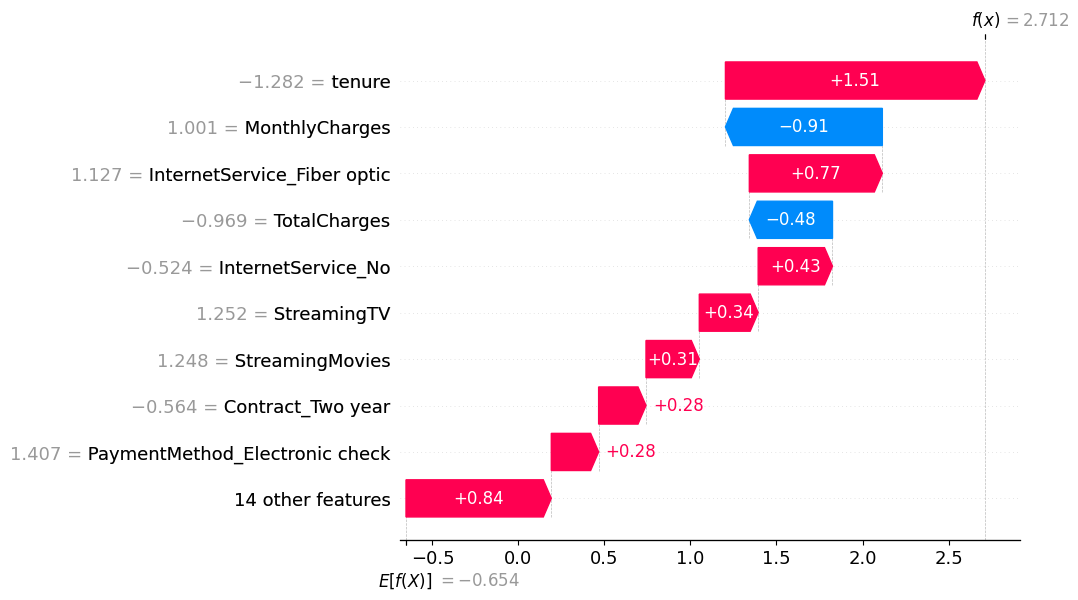

In [45]:
# ============================================
# 2. Waterfall — explication client individuel
# ============================================

# Prenons un client qui va churner (prédiction haute)
idx = np.argmax(model_balanced.predict_proba(X_test)[:, 1])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test[idx],
        feature_names=feature_names
    ),
    max_display=10
)

In [46]:

# ============================================
# Clients à risque
# ============================================

# Reconstruire le dataframe test avec les probabilités
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_df['churn_proba'] = model_balanced.predict_proba(X_test)[:, 1]
X_test_df['churn_predicted'] = model_balanced.predict(X_test)

# Top 10 clients à risque
top_risk = X_test_df.sort_values('churn_proba', ascending=False).head(10)

print("Top 10 clients à risque :")
print(top_risk[['tenure', 'MonthlyCharges', 'TotalCharges', 
                 'Contract_Two year', 'InternetService_Fiber optic',
                 'churn_proba']].to_string())

# ============================================
# Traduction business
# ============================================
print("\n" + "="*50)
print("RECOMMANDATIONS BUSINESS")
print("="*50)

high_risk = X_test_df[X_test_df['churn_proba'] >= 0.7]
medium_risk = X_test_df[(X_test_df['churn_proba'] >= 0.4) & (X_test_df['churn_proba'] < 0.7)]
low_risk = X_test_df[X_test_df['churn_proba'] < 0.4]

print(f"\n🔴 Risque élevé  (>70%)  : {len(high_risk)} clients  → Offre de rétention immédiate")
print(f"🟡 Risque moyen (40-70%) : {len(medium_risk)} clients → Campagne email + remise")
print(f"🟢 Risque faible (<40%)  : {len(low_risk)} clients  → Programme fidélité")

print(f"\nRevenu mensuel à risque élevé : R$ {round(high_risk['MonthlyCharges'].sum(), 2):,}")
print(f"Revenu mensuel à risque moyen : R$ {round(medium_risk['MonthlyCharges'].sum(), 2):,}")

Top 10 clients à risque :
        tenure  MonthlyCharges  TotalCharges  Contract_Two year  InternetService_Fiber optic  churn_proba
1090 -1.281624        1.001148     -0.968657          -0.563822                     1.126512     0.937708
1221 -1.281624        1.012763     -0.968503          -0.563822                     1.126512     0.926267
1175 -1.037389        1.138860     -0.718240          -0.563822                     1.126512     0.926168
1164 -1.037389        1.228456     -0.702698          -0.563822                     1.126512     0.920770
889  -1.240918        0.634470     -0.928724          -0.563822                     1.126512     0.920700
1109 -1.281624        0.667654     -0.973069          -0.563822                     1.126512     0.920273
1138 -1.200212        1.359531     -0.863480          -0.563822                     1.126512     0.919150
647  -1.200212        1.195272     -0.865544          -0.563822                     1.126512     0.918498
995  -1.037389      

In [47]:
# ============================================
# Inverser la normalisation pour lisibilité
# ============================================
X_test_original = pd.DataFrame(
    scaler.inverse_transform(X_test),
    columns=feature_names
)
X_test_original['churn_proba'] = model_balanced.predict_proba(X_test)[:, 1]
X_test_original['risk_level'] = pd.cut(
    X_test_original['churn_proba'],
    bins=[0, 0.4, 0.7, 1],
    labels=['🟢 Low', '🟡 Medium', '🔴 High']
)

# Top 10 clients à risque
top_risk = X_test_original.sort_values('churn_proba', ascending=False).head(10)

print("Top 10 clients à risque :")
print(top_risk[['tenure', 'MonthlyCharges', 'TotalCharges',
                 'Contract_Two year', 'InternetService_Fiber optic',
                 'churn_proba', 'risk_level']].to_string())

# Recommandations business
high_risk = X_test_original[X_test_original['churn_proba'] >= 0.7]
medium_risk = X_test_original[(X_test_original['churn_proba'] >= 0.4) & (X_test_original['churn_proba'] < 0.7)]
low_risk = X_test_original[X_test_original['churn_proba'] < 0.4]

print("\n" + "="*50)
print("RECOMMANDATIONS BUSINESS")
print("="*50)
print(f"\n🔴 Risque élevé  (>70%)  : {len(high_risk)} clients  → Offre de rétention immédiate")
print(f"🟡 Risque moyen (40-70%) : {len(medium_risk)} clients → Campagne email + remise")
print(f"🟢 Risque faible (<40%)  : {len(low_risk)} clients  → Programme fidélité")
print(f"\nRevenu mensuel à risque élevé : ${round(high_risk['MonthlyCharges'].sum(), 2):,}")
print(f"Revenu mensuel à risque moyen : ${round(medium_risk['MonthlyCharges'].sum(), 2):,}")
print(f"Revenu total à risque         : ${round((high_risk['MonthlyCharges'].sum() + medium_risk['MonthlyCharges'].sum()), 2):,}")

Top 10 clients à risque :
      tenure  MonthlyCharges  TotalCharges  Contract_Two year  InternetService_Fiber optic  churn_proba risk_level
1090     1.0           95.10         95.10                0.0                          1.0     0.937708     🔴 High
1221     1.0           95.45         95.45                0.0                          1.0     0.926267     🔴 High
1175     7.0           99.25        665.45                0.0                          1.0     0.926168     🔴 High
1164     7.0          101.95        700.85                0.0                          1.0     0.920770     🔴 High
889      2.0           84.05        186.05                0.0                          1.0     0.920700     🔴 High
1109     1.0           85.05         85.05                0.0                          1.0     0.920273     🔴 High
1138     3.0          105.90        334.65                0.0                          1.0     0.919150     🔴 High
647      3.0          100.95        329.95            